# 🎌 AniSense — Anime Sentiment Intelligence & Recommendation Engine

> **Mini Project | Natural Language Processing**  
> **Author:** Himanshu Jadhav (Roll No: TE-32)  
> **Subject:** Natural Language Processing (NLP)

---

## 📌 Project Abstract

**AniSense** is an end-to-end NLP pipeline for the anime domain.  
It combines **Sentiment Analysis**, **Keyword Extraction**, **Genre Classification**,  
and a **Content-Based Recommendation Engine**, applied to a small dataset of **126 anime reviews  
across 22 popular anime titles** (loaded from `data/`; counts are printed in Section 3).

| Component | Technique |
|:---|:---|
| Text Preprocessing | Regex cleaning, stopword removal, lemmatisation |
| Sentiment Labelling | Rating-to-sentiment mapping (≥7 Positive, 5–6 Neutral, ≤4 Negative) |
| Sentiment Classification | TF-IDF + Naive Bayes / Logistic Regression / SVM, **stratified cross-validation**, compared with a majority-class baseline |
| Keyword Extraction | TF-IDF top-N per anime |
| Genre Classification | TF-IDF + linear classifiers, leakage-free evaluation (leave-one-out / grouped CV) |
| Recommendation Engine | TF-IDF document vectors + Cosine Similarity |
| Evaluation | Accuracy, Macro/Weighted F1, Confusion Matrix, always against a baseline |

```
INPUT: Anime Title / Review Text
       │
       ▼
  Text Preprocessing → Sentiment Classifier
                    → Keyword Extractor
                    → Recommendation Engine
       │
OUTPUT: Sentiment Label + Top Keywords + Top-5 Recommendations
```

> ⚠️ **Honest scope note:** 126 reviews is a *toy* dataset and the classes are heavily imbalanced
> (~78% Positive). Results here demonstrate the pipeline; they are not evidence of production-grade accuracy.

## 1. 🧠 Theory

### 1.1 Sentiment Analysis
Determines emotional polarity — Positive, Neutral, or Negative.

**ML approach (TF-IDF + Logistic Regression):**
$$P(c \mid \text{review}) = \text{softmax}\big(W\,\phi(\text{review}) + \mathbf{b}\big)_c$$

**Naive Bayes:**
$$\hat{y} = \arg\max_c P(c) \prod_{i} P(x_i | c)$$

### 1.2 TF-IDF Keyword Extraction
scikit-learn's default (smoothed) formulation, followed by L2 normalisation of each document vector:
$$\text{TF-IDF}(t, d) = f_{t,d} \cdot \left(\ln\frac{1 + |D|}{1 + \text{df}(t)} + 1\right)$$
(with `sublinear_tf=True`, $f_{t,d}$ is replaced by $1 + \ln f_{t,d}$).

### 1.3 Cosine Similarity for Recommendations
$$\text{sim}(A, B) = \frac{\vec{A} \cdot \vec{B}}{\|\vec{A}\| \cdot \|\vec{B}\|}$$

Two anime are **similar** if their aggregated TF-IDF review vectors point in the same direction.

### 1.4 Evaluation on imbalanced data
When one class is ~78% of the data, **accuracy is misleading**: a model that always answers "Positive" scores ~78%.
We therefore report **Macro-F1** (every class counts equally) and always include a **majority-class baseline**.

## 2. ⚙️ Imports & Setup

In [1]:
import re
import json
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
for pkg in ['punkt', 'punkt_tab', 'stopwords', 'wordnet']:
    nltk.download(pkg, quiet=True)
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold, GroupKFold, LeaveOneOut,
    cross_validate, cross_val_predict,
)
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
from sklearn.metrics.pairwise import cosine_similarity

RANDOM_STATE = 42
sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

print('Environment ready.')

Environment ready.


## 3. 📊 Load Dataset

In [2]:
# Auto-detect dataset directory across local workspace and Google Colab
candidates = [
    Path("data"),
    Path("Mini-Project-Extra/data"),
    Path("/content/data"),
    Path("/content/Mini-Project-Extra/data"),
    Path("/content"),
    Path("."),
]

DATA_DIR = next(
    (p for p in candidates if (p / "anime_meta.json").exists() and (p / "anime_reviews.json").exists()),
    None
)

if DATA_DIR is None:
    raise FileNotFoundError(
        "anime_meta.json and anime_reviews.json not found. Put them in ./data, "
        "./Mini-Project-Extra/data, or /content (Colab: upload them via the Files panel)."
    )

print(f"Dataset located at: {DATA_DIR.resolve()}")

with (DATA_DIR / "anime_meta.json").open(encoding="utf-8") as f:
    ANIME_META = json.load(f)

with (DATA_DIR / "anime_reviews.json").open(encoding="utf-8") as f:
    raw_reviews = json.load(f)

df = pd.DataFrame(raw_reviews, columns=["anime_title", "rating", "review_text"])

# ---- data validation (fail loudly instead of silently producing garbage) ----
missing_titles = sorted(set(df["anime_title"]) - set(ANIME_META))
if missing_titles:
    raise KeyError(f"Missing metadata for anime titles: {missing_titles}")
assert df["rating"].between(1, 10).all(), "Ratings must be within 1-10"
assert df["review_text"].str.strip().str.len().gt(0).all(), "Empty review text found"

df["genre"] = df["anime_title"].map(lambda title: ANIME_META[title]["genre"])

print(f"Reviews loaded  : {len(df)}")
print(f"Anime titles    : {df['anime_title'].nunique()}")
print(f"Genres          : {sorted(df['genre'].unique())}")
print(f"Rating range    : {df['rating'].min()} - {df['rating'].max()}")
print()
print(df.head(6).to_string())

Dataset located at: /home/claude/work/Mini-Project-Extra/data
Reviews loaded  : 126
Anime titles    : 22
Genres          : ['Action', 'Adventure', 'Drama', 'Romance', 'Sci-Fi', 'Thriller']
Rating range    : 2 - 10

       anime_title  rating                                                                                                                                                                                       review_text   genre
0  Attack on Titan      10  An absolute masterpiece. The storytelling is unparalleled, the animation during titan battles is breathtaking and the plot twists completely redefine the entire series. Season 4 is peak anime.  Action
1  Attack on Titan       9       Brilliant world-building and morally complex characters. Eren Yeager has one of the most shocking character arcs I have ever seen in fiction. The final season had me emotional throughout.  Action
2  Attack on Titan      10                                    The lore is astonishing. Every myste

## 4. 🔍 Sentiment Labelling & Exploratory Data Analysis

In [3]:
def rating_to_sentiment(r):
    if r >= 7:   return 'Positive'
    elif r >= 5: return 'Neutral'
    else:        return 'Negative'

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

print('Sentiment distribution:')
print(df['sentiment'].value_counts().to_string())
print()
MAJORITY_SHARE = df['sentiment'].value_counts(normalize=True).max()
print(f'Majority-class share: {MAJORITY_SHARE*100:.1f}%  <- any classifier must beat this accuracy to be useful')
print()
print('Genre distribution:')
print(df['genre'].value_counts().to_string())

Sentiment distribution:
sentiment
Positive    98
Neutral     20
Negative     8

Majority-class share: 77.8%  <- any classifier must beat this accuracy to be useful

Genre distribution:
genre
Action       32
Adventure    23
Romance      22
Sci-Fi       21
Thriller     19
Drama         9


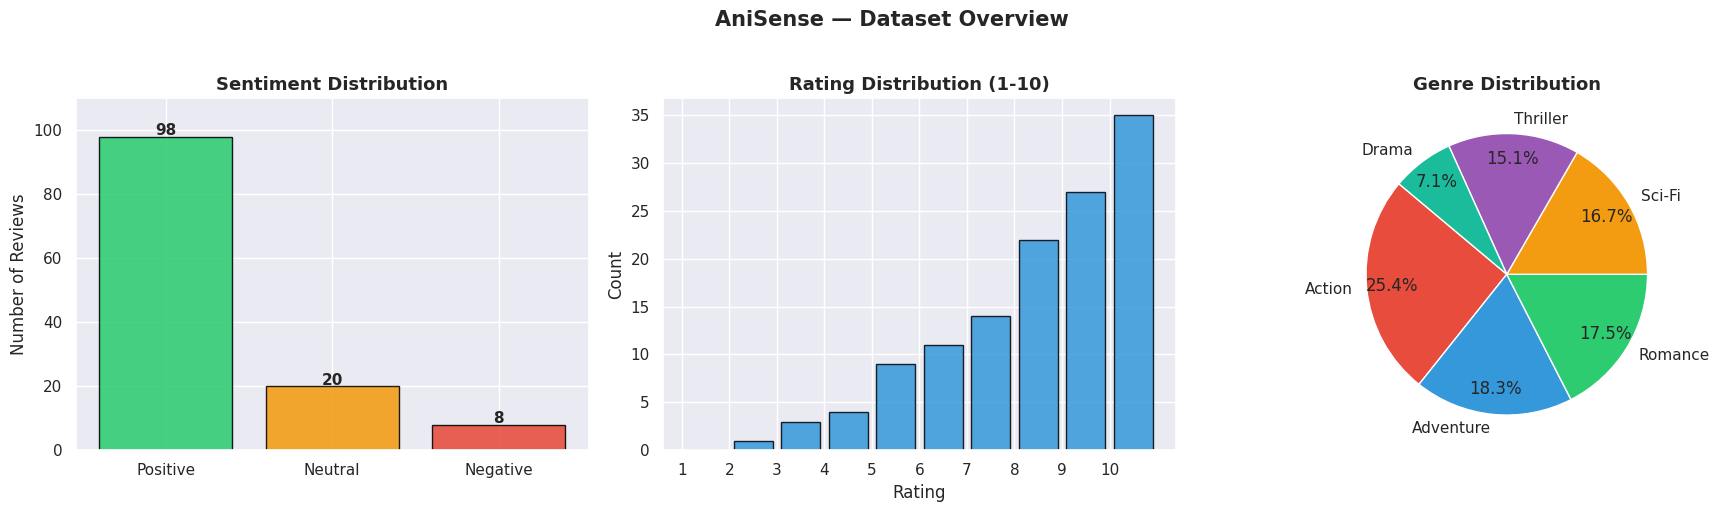

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sentiment bar chart
sent_counts = df['sentiment'].value_counts()
sent_colors = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}
bars = axes[0].bar(sent_counts.index, sent_counts.values,
                   color=[sent_colors[s] for s in sent_counts.index],
                   edgecolor='black', alpha=0.88)
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Sentiment Distribution', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Reviews')
axes[0].set_ylim(0, sent_counts.max() + 12)

# Rating histogram
axes[1].hist(df['rating'], bins=range(1, 12), color='#3498db',
             edgecolor='black', alpha=0.85, rwidth=0.82)
axes[1].set_title('Rating Distribution (1-10)', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(1, 11))

# Genre pie chart
genre_counts = df['genre'].value_counts()
palette = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6','#1abc9c']
axes[2].pie(genre_counts.values, labels=genre_counts.index,
            autopct='%1.1f%%', colors=palette, startangle=140, pctdistance=0.82)
axes[2].set_title('Genre Distribution', fontweight='bold', fontsize=13)

plt.suptitle('AniSense — Dataset Overview', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


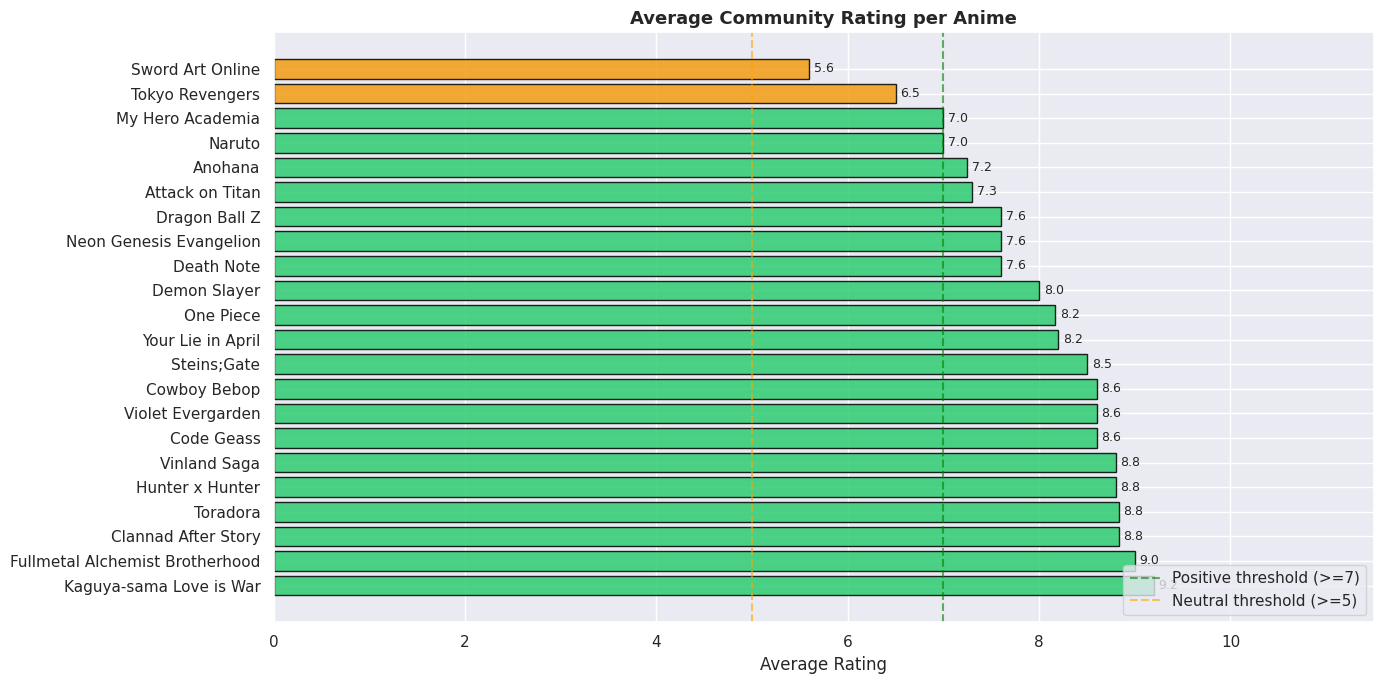

In [5]:
# Average rating per anime — horizontal bar chart
avg_rating = df.groupby('anime_title')['rating'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['#2ecc71' if v >= 7 else '#f39c12' if v >= 5 else '#e74c3c'
          for v in avg_rating.values]
bars = ax.barh(avg_rating.index, avg_rating.values,
               color=colors, edgecolor='black', alpha=0.85)
ax.axvline(7, color='green',  linestyle='--', alpha=0.6, label='Positive threshold (>=7)')
ax.axvline(5, color='orange', linestyle='--', alpha=0.6, label='Neutral threshold (>=5)')
for bar, val in zip(bars, avg_rating.values):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}', va='center', fontsize=9)
ax.set_title('Average Community Rating per Anime', fontweight='bold', fontsize=13)
ax.set_xlabel('Average Rating')
ax.set_xlim(0, 11.5)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 5. 🧹 Text Preprocessing Pipeline

In [6]:
def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in STOP_WORDS and len(t) > 2]
    return ' '.join(tokens)

df['clean_review'] = df['review_text'].apply(preprocess)

vocab_size = len(set(' '.join(df['clean_review']).split()))
print(f'Vocabulary size after preprocessing: {vocab_size} unique tokens')
print()
print('Sample:')
for _, row in df.head(3).iterrows():
    print(f'  RAW   : {row["review_text"][:85]}...')
    print(f'  CLEAN : {row["clean_review"][:85]}...')
    print()


Vocabulary size after preprocessing: 933 unique tokens

Sample:
  RAW   : An absolute masterpiece. The storytelling is unparalleled, the animation during titan...
  CLEAN : absolute masterpiece storytelling unparalleled animation titan battle breathtaking pl...

  RAW   : Brilliant world-building and morally complex characters. Eren Yeager has one of the m...
  CLEAN : brilliant world building morally complex character eren yeager one shocking character...

  RAW   : The lore is astonishing. Every mystery introduced in season one pays off brilliantly....
  CLEAN : lore astonishing every mystery introduced season one pay brilliantly animation mappa ...



## 6. 🎭 Sentiment Analysis

### 6.1 Lexicon-Based Baseline


In [7]:
POSITIVE_WORDS = {
    'masterpiece','brilliant','outstanding','exceptional','perfect','stunning',
    'breathtaking','incredible','amazing','fantastic','excellent','best','greatest',
    'legendary','iconic','beautiful','emotional','magnificent','powerful','compelling',
    'superb','flawless','profound','inspiring','moving','devastating','cathartic',
    'transcendent','unmatched','unparalleled','extraordinary','phenomenal','genius',
    'timeless','classic','heartbreaking','immaculate','riveting','unforgettable'
}
NEGATIVE_WORDS = {
    'disappointing','bad','terrible','awful','boring','overrated','shallow',
    'mediocre','weak','poor','predictable','frustrating','annoying','tiresome',
    'inconsistent','underwhelming','forgettable','unbearable','repetitive',
    'cliche','generic','formulaic','contrived','cartoonish','rushed','sloppy',
    'tedious','regressive','pretentious','abrupt','insufferable','anticlimactic'
}

def lexicon_sentiment(text):
    tokens = set(text.split())
    pos = len(tokens & POSITIVE_WORDS)
    neg = len(tokens & NEGATIVE_WORDS)
    if pos > neg:   return 'Positive'
    elif neg > pos: return 'Negative'
    else:           return 'Neutral'

df['lexicon_pred'] = df['clean_review'].apply(lexicon_sentiment)
lex_acc = accuracy_score(df['sentiment'], df['lexicon_pred'])
lex_f1  = f1_score(df['sentiment'], df['lexicon_pred'], average='macro')
print(f'Lexicon-Based Accuracy : {lex_acc*100:.2f}%   (majority baseline: {MAJORITY_SHARE*100:.2f}%)')
print(f'Lexicon-Based Macro-F1 : {lex_f1:.4f}')
print()
print(classification_report(df['sentiment'], df['lexicon_pred'], zero_division=0))

# Sanity check on the lexicon itself
vocab = set(' '.join(df['clean_review']).split())
print(f'Lexicon words found in this corpus: '
      f'{len(POSITIVE_WORDS & vocab)}/{len(POSITIVE_WORDS)} positive, '
      f'{len(NEGATIVE_WORDS & vocab)}/{len(NEGATIVE_WORDS)} negative')
print('NOTE: the word lists were written with this dataset in mind and no negation handling exists '
      '("not good" counts as positive), so these scores are optimistic and NOT directly '
      'comparable to the cross-validated ML scores below.')

Lexicon-Based Accuracy : 73.02%   (majority baseline: 77.78%)
Lexicon-Based Macro-F1 : 0.6359

              precision    recall  f1-score   support

    Negative       0.71      0.62      0.67         8
     Neutral       0.33      0.55      0.42        20
    Positive       0.88      0.78      0.83        98

    accuracy                           0.73       126
   macro avg       0.64      0.65      0.64       126
weighted avg       0.79      0.73      0.75       126

Lexicon words found in this corpus: 34/39 positive, 17/32 negative
NOTE: the word lists were written with this dataset in mind and no negation handling exists ("not good" counts as positive), so these scores are optimistic and NOT directly comparable to the cross-validated ML scores below.


### 6.2 TF-IDF + ML Classifiers (stratified cross-validation)

**Why not a single 80/20 split?** With 126 reviews and only 8 Negative samples, a 20% test set holds
~2 Negative reviews — any metric on it is noise. Worse, with plain `fit()` on this imbalance,
Naive Bayes / Logistic Regression / SVM all collapse to "always predict Positive" and become
indistinguishable from a majority-class baseline.

Fixes applied:
1. **5×5 repeated stratified CV** (25 train/test rounds) for mean ± std of Accuracy and Macro-F1.
2. **TF-IDF is fitted inside a `Pipeline`**, so each fold's vectoriser only sees that fold's training text (no leakage).
3. **`class_weight='balanced'`** for LR/SVM and **Complement NB** (designed for imbalanced text) so minority classes are not ignored.
4. A **majority-class baseline** row to keep the comparison honest.

In [8]:
X = df['clean_review']
y = df['sentiment']
LABELS = ['Positive', 'Neutral', 'Negative']

def make_pipe(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1, 2), sublinear_tf=True)),
        ('clf', clf),
    ])

models = {
    'Majority baseline':   DummyClassifier(strategy='most_frequent'),
    'Naive Bayes (MNB)':   MultinomialNB(alpha=0.5),
    'Complement NB':       ComplementNB(alpha=0.3),
    'Logistic Regression': LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE),
    'Linear SVM':          LinearSVC(C=1.0, class_weight='balanced', random_state=RANDOM_STATE),
}

cv_rep  = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
cv_once = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

rows, oof_preds = {}, {}
for name, clf in models.items():
    pipe = make_pipe(clf)
    cv_res = cross_validate(pipe, X, y, cv=cv_rep,
                            scoring=['accuracy', 'f1_macro', 'f1_weighted'])
    rows[name] = {
        'Accuracy (%)': round(cv_res['test_accuracy'].mean() * 100, 2),
        'Acc std (%)':  round(cv_res['test_accuracy'].std() * 100, 2),
        'F1 Macro':     round(cv_res['test_f1_macro'].mean(), 4),
        'F1 Macro std': round(cv_res['test_f1_macro'].std(), 4),
        'F1 Weighted':  round(cv_res['test_f1_weighted'].mean(), 4),
    }
    # out-of-fold predictions: every review is predicted by a model that never saw it
    oof_preds[name] = cross_val_predict(pipe, X, y, cv=cv_once)

results_df = pd.DataFrame(rows).T
print('=== ML CLASSIFIER COMPARISON (5x5 stratified CV, mean ± std) ===')
print(results_df.to_string())

=== ML CLASSIFIER COMPARISON (5x5 stratified CV, mean ± std) ===
                     Accuracy (%)  Acc std (%)  F1 Macro  F1 Macro std  F1 Weighted
Majority baseline           77.78         1.84    0.2916        0.0039       0.6808
Naive Bayes (MNB)           77.78         1.84    0.2916        0.0039       0.6808
Complement NB               82.86         5.10    0.4732        0.0975       0.7925
Logistic Regression         80.32         3.78    0.3718        0.1011       0.7289
Linear SVM                  79.05         2.59    0.3352        0.0637       0.7065


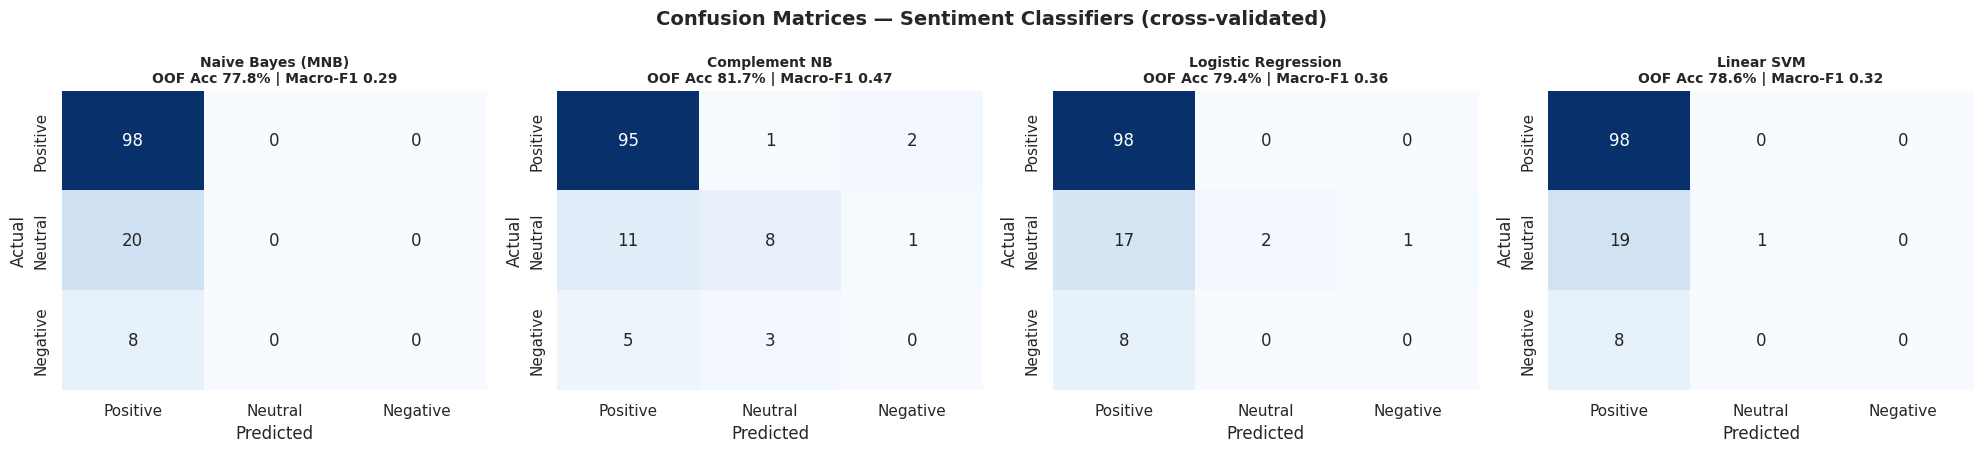

In [9]:
# Confusion matrices from out-of-fold predictions (all 126 reviews, none seen during training)
plot_models = [m for m in models if m != 'Majority baseline']
fig, axes = plt.subplots(1, len(plot_models), figsize=(5 * len(plot_models), 4.6))

for ax, name in zip(axes, plot_models):
    preds = oof_preds[name]
    cm = confusion_matrix(y, preds, labels=LABELS)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_title(f'{name}\nOOF Acc {accuracy_score(y, preds)*100:.1f}% | '
                 f'Macro-F1 {f1_score(y, preds, average="macro"):.2f}',
                 fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Sentiment Classifiers (cross-validated)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

### 6.3 Feature Importance — Top Keywords per Sentiment Class

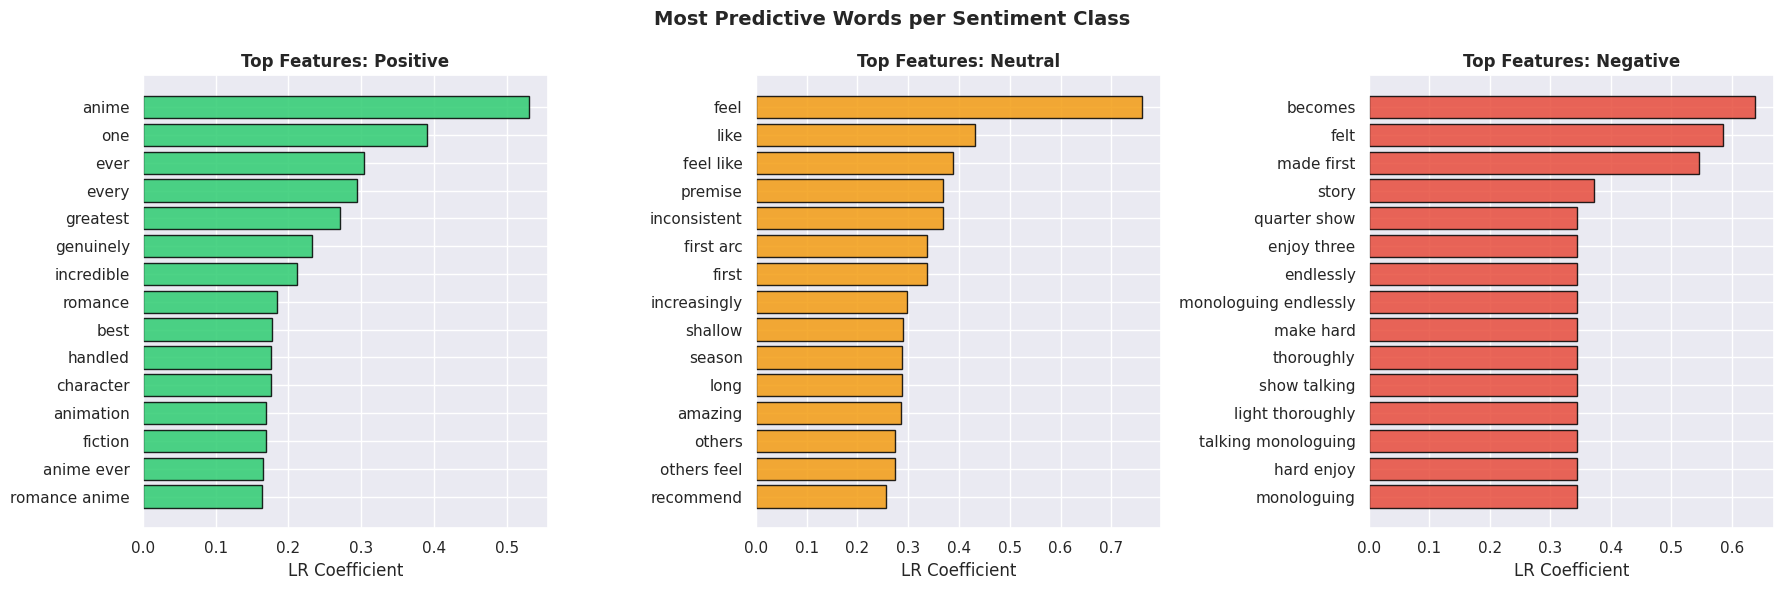

In [10]:
# Final model fitted on ALL labelled reviews (used for feature inspection and for predicting new text).
# Its performance is the cross-validated figure above, NOT its score on its own training data.
final_pipe = make_pipe(models['Logistic Regression']).fit(X, y)
tfidf      = final_pipe.named_steps['tfidf']
lr_clf     = final_pipe.named_steps['clf']
feat_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
class_colors = {'Positive': '#2ecc71', 'Neutral': '#f39c12', 'Negative': '#e74c3c'}

for ax, (cls, color) in zip(axes, class_colors.items()):
    cls_idx  = list(lr_clf.classes_).index(cls)
    coefs    = lr_clf.coef_[cls_idx]
    top_idx  = np.argsort(coefs)[-15:][::-1]

    ax.barh(feat_names[top_idx][::-1], coefs[top_idx][::-1],
            color=color, alpha=0.85, edgecolor='black')
    ax.set_title(f'Top Features: {cls}', fontweight='bold', fontsize=12)
    ax.set_xlabel('LR Coefficient')

plt.suptitle('Most Predictive Words per Sentiment Class', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

## 7. 🔑 Keyword & Theme Extraction per Anime

We aggregate all reviews per anime and extract TF-IDF top keywords to reveal each anime's **signature community themes**.
Terms appearing in more than half of the anime documents (`max_df=0.5`) are dropped as non-distinctive, and
overlapping n-grams (e.g. *spike* / *spike spiegel* / *spiegel*) are de-duplicated.

In [11]:
anime_corpus   = df.groupby('anime_title')['clean_review'].apply(lambda x: ' '.join(x))
anime_vec      = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), max_df=0.5, sublinear_tf=True)
anime_mat      = anime_vec.fit_transform(anime_corpus)
anime_features = anime_vec.get_feature_names_out()

def top_keywords(title, n=5):
    """Top-n distinctive terms for an anime, skipping terms that overlap an already-chosen term."""
    row   = anime_mat[list(anime_corpus.index).index(title)].toarray().ravel()
    chosen = []
    for i in np.argsort(row)[::-1]:
        if row[i] <= 0:
            break
        term = anime_features[i]
        if any(term in c or c in term for c, _ in chosen):
            continue
        chosen.append((term, row[i]))
        if len(chosen) == n:
            break
    return chosen

kw_table = {t: [f'{k} ({s:.3f})' for k, s in top_keywords(t)] for t in anime_corpus.index}
kw_df = pd.DataFrame.from_dict(kw_table, orient='index',
                               columns=[f'KW{i+1}' for i in range(5)])
print('=== TOP KEYWORDS PER ANIME ===')
print(kw_df.to_string())

=== TOP KEYWORDS PER ANIME ===
                                                                  KW1                        KW2                         KW3                            KW4                       KW5
Anohana                                                 short (0.230)              grief (0.203)        supernatural (0.203)                    way (0.157)    empathy finale (0.136)
Attack on Titan                                        season (0.163)       titan battle (0.156)           political (0.137)              animation (0.131)              plot (0.124)
Clannad After Story                                   clannad (0.221)               love (0.157)               drama (0.157)                 family (0.157)            moment (0.143)
Code Geass                                            lelouch (0.277)             season (0.176)              ending (0.165)  cliffhanger legendary (0.132)     excellent get (0.132)
Cowboy Bebop                                            spi

## 8. 🏷️ Genre Classification from Plot Summaries

**Original bug (fixed):** the first version "augmented" each plot by shuffling its words, then did a random
train/test split. A bag-of-words model cannot tell a shuffled plot from the original (identical TF-IDF vectors),
so near-duplicates of every training plot ended up in the test set — hence a meaningless 100% accuracy.

**Correct evaluation here:**
* No augmentation (shuffling adds no information to a bag-of-words model).
* **Leave-one-out CV on the 22 plots** — each plot is predicted by a model that never saw it.
* A second check on the **126 reviews with `GroupKFold` by anime**, so all reviews of one anime stay on the same side of the split.
* Both are compared against a **majority-class baseline**.

With only 22 labelled anime (2 in *Drama*) and subjective single-label genres, expect weak results.

(a) PLOT SUMMARIES, leave-one-out CV  (n=22, majority baseline 22.7%)
    Naive Bayes          accuracy =   0.0%


    Logistic Regression  accuracy =   0.0%
    Linear SVM           accuracy =   0.0%
    (0% is below the majority baseline: with so little signal, leave-one-out removes the held-out anime from its own genre, which systematically pushes the prediction to a different one. Read it as "no learnable signal", not as a bug.)

(b) REVIEWS, GroupKFold by anime  (n=126, majority baseline 25.4%)
    Naive Bayes          accuracy =  19.8%   macro-F1 = 0.125
    Logistic Regression  accuracy =  26.2%   macro-F1 = 0.188


    Linear SVM           accuracy =  27.0%   macro-F1 = 0.199

Verdict: best grouped-CV model (Linear SVM) reaches 27.0% — only marginally above the 25.4% majority baseline. Genre is not reliably learnable from this little data.


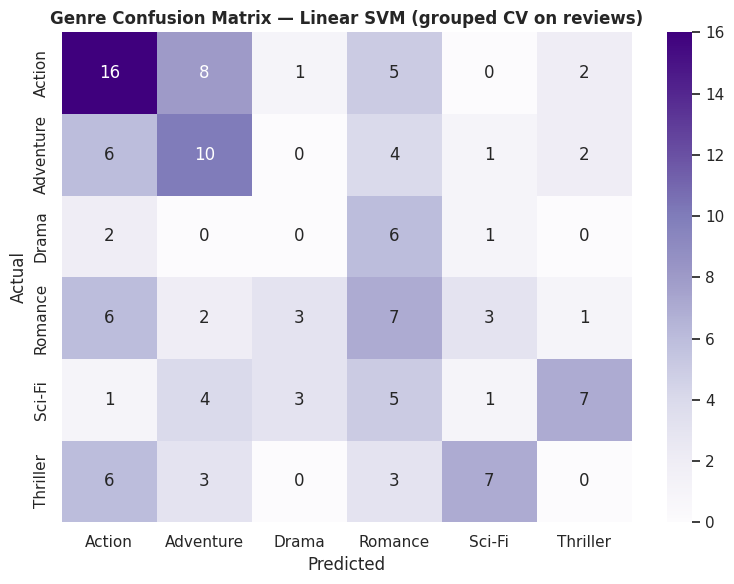

In [12]:
plot_df = pd.DataFrame([
    {'title': t, 'plot': m['plot'], 'genre': m['genre']}
    for t, m in ANIME_META.items()
])

def genre_pipe(clf):
    return Pipeline([('tfidf', TfidfVectorizer(stop_words='english', sublinear_tf=True)), ('clf', clf)])

# (a) Plot summaries, leave-one-out
base_plot = plot_df['genre'].value_counts(normalize=True).max()
print(f'(a) PLOT SUMMARIES, leave-one-out CV  (n={len(plot_df)}, majority baseline {base_plot*100:.1f}%)')
for name, clf in {'Naive Bayes': MultinomialNB(alpha=0.5),
                  'Logistic Regression': LogisticRegression(C=10, max_iter=1000),
                  'Linear SVM': LinearSVC()}.items():
    p = cross_val_predict(genre_pipe(clf), plot_df['plot'], plot_df['genre'], cv=LeaveOneOut())
    print(f'    {name:<20s} accuracy = {accuracy_score(plot_df["genre"], p)*100:5.1f}%')

print('    (0% is below the majority baseline: with so little signal, leave-one-out removes the held-out anime '
      'from its own genre, which systematically pushes the prediction to a different one. '
      'Read it as "no learnable signal", not as a bug.)')

# (b) Reviews, grouped by anime
base_rev = df['genre'].value_counts(normalize=True).max()
print()
print(f'(b) REVIEWS, GroupKFold by anime  (n={len(df)}, majority baseline {base_rev*100:.1f}%)')
genre_oof = {}
for name, clf in {'Naive Bayes': MultinomialNB(alpha=0.5),
                  'Logistic Regression': LogisticRegression(C=10, class_weight='balanced', max_iter=1000),
                  'Linear SVM': LinearSVC(class_weight='balanced')}.items():
    p = cross_val_predict(genre_pipe(clf), df['clean_review'], df['genre'],
                          cv=GroupKFold(n_splits=5), groups=df['anime_title'])
    genre_oof[name] = p
    print(f'    {name:<20s} accuracy = {accuracy_score(df["genre"], p)*100:5.1f}%   '
          f'macro-F1 = {f1_score(df["genre"], p, average="macro"):.3f}')

best_g   = max(genre_oof, key=lambda k: f1_score(df['genre'], genre_oof[k], average='macro'))
best_acc = accuracy_score(df['genre'], genre_oof[best_g])
verdict  = ('only marginally above' if best_acc > base_rev else 'NOT above')
print(f'\nVerdict: best grouped-CV model ({best_g}) reaches {best_acc*100:.1f}% — {verdict} the '
      f'{base_rev*100:.1f}% majority baseline. Genre is not reliably learnable from this little data.')

# Confusion matrix of the best grouped-CV model
genre_labels = sorted(df['genre'].unique())
cm_g = confusion_matrix(df['genre'], genre_oof[best_g], labels=genre_labels)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_g, annot=True, fmt='d', cmap='Purples',
            xticklabels=genre_labels, yticklabels=genre_labels, ax=ax)
ax.set_title(f'Genre Confusion Matrix — {best_g} (grouped CV on reviews)', fontweight='bold', fontsize=12)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## 9. 🎯 Content-Based Recommendation Engine

Cosine similarity on aggregated review TF-IDF vectors — given an anime you liked, find the **top-N most similar** ones.

> **Limitation:** similarity is computed from *review wording* (4–10 reviews per anime), so it reflects how people
> *talk about* a show (e.g. "season", "arc", "animation") as much as what the show *is*. There is no ground truth
> in this dataset, so recommendation quality cannot be scored objectively — treat the output as a demo.

In [13]:
sim_matrix = cosine_similarity(anime_mat)
anime_list = list(anime_corpus.index)
sim_df     = pd.DataFrame(sim_matrix, index=anime_list, columns=anime_list)

def recommend(anime_name, top_n=5):
    if anime_name not in sim_df.index:
        print(f'Not found: {anime_name}')
        return pd.DataFrame()

    scores = sim_df[anime_name].drop(anime_name).sort_values(ascending=False)
    rows   = []
    for title, score in scores.head(top_n).items():
        sub = df[df['anime_title'] == title]
        rows.append({
            'Recommended Anime': title,
            'Genre':             ANIME_META[title]['genre'],
            'Avg Rating':        round(sub['rating'].mean(), 1),
            'Similarity Score':  round(score, 4),
            'Positive %':        f"{(sub['sentiment'] == 'Positive').mean()*100:.0f}%",
        })
    return pd.DataFrame(rows)

# Demo
for query in ['Attack on Titan', 'Steins;Gate', 'Your Lie in April', 'Cowboy Bebop']:
    print(f'If you liked: {query}')
    print(recommend(query, top_n=5).to_string(index=False))
    print()

If you liked: Attack on Titan


              Recommended Anime     Genre  Avg Rating  Similarity Score Positive %
                     Code Geass  Thriller         8.6            0.1825        80%
               My Hero Academia    Action         7.0            0.1491        60%
                   Vinland Saga    Action         8.8            0.1321       100%
Fullmetal Alchemist Brotherhood Adventure         9.0            0.1239       100%
                   Demon Slayer    Action         8.0            0.1189        71%

If you liked: Steins;Gate
Recommended Anime    Genre  Avg Rating  Similarity Score Positive %
         Toradora  Romance         8.8            0.1609       100%
       Death Note Thriller         7.6            0.1315        70%
  Tokyo Revengers Thriller         6.5            0.1013        50%
  Attack on Titan   Action         7.3            0.0971        70%
 Sword Art Online   Sci-Fi         5.6            0.0949        40%

If you liked: Your Lie in April
  Recommended Anime    Genre  Avg 

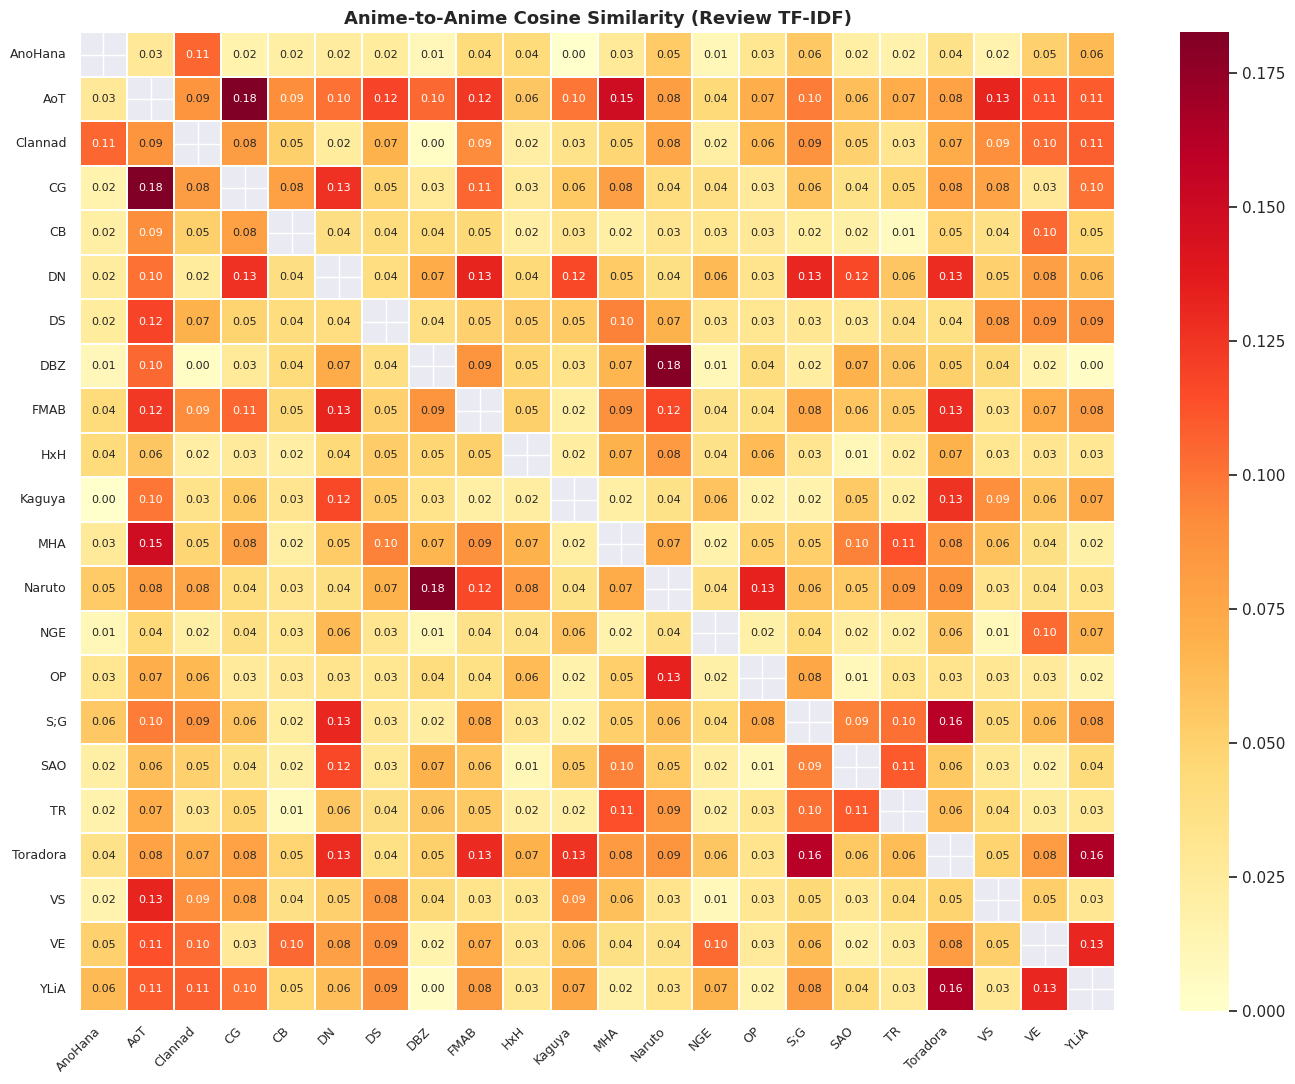

In [14]:
# Similarity heatmap
abbrev = {
    'Fullmetal Alchemist Brotherhood': 'FMAB',
    'Neon Genesis Evangelion': 'NGE',
    'Your Lie in April': 'YLiA',
    'Hunter x Hunter': 'HxH',
    'My Hero Academia': 'MHA',
    'Dragon Ball Z': 'DBZ',
    'Sword Art Online': 'SAO',
    'Violet Evergarden': 'VE',
    'Vinland Saga': 'VS',
    'Tokyo Revengers': 'TR',
    'Code Geass': 'CG',
    'Death Note': 'DN',
    'Cowboy Bebop': 'CB',
    'Steins;Gate': 'S;G',
    'Demon Slayer': 'DS',
    'Naruto': 'Naruto',
    'One Piece': 'OP',
    'Anohana': 'AnoHana',
    'Attack on Titan': 'AoT',
    'Toradora': 'Toradora',
    'Clannad After Story': 'Clannad',
    'Kaguya-sama Love is War': 'Kaguya',
}
short_labels = [abbrev.get(t, t[:10]) for t in anime_list]
mask = np.eye(len(anime_list), dtype=bool)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(sim_df.values, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=short_labels, yticklabels=short_labels,
            mask=mask, linewidths=0.3, ax=ax, annot_kws={'size': 8})
ax.set_title('Anime-to-Anime Cosine Similarity (Review TF-IDF)',
             fontweight='bold', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

## 10. 📊 Sentiment Profile per Anime

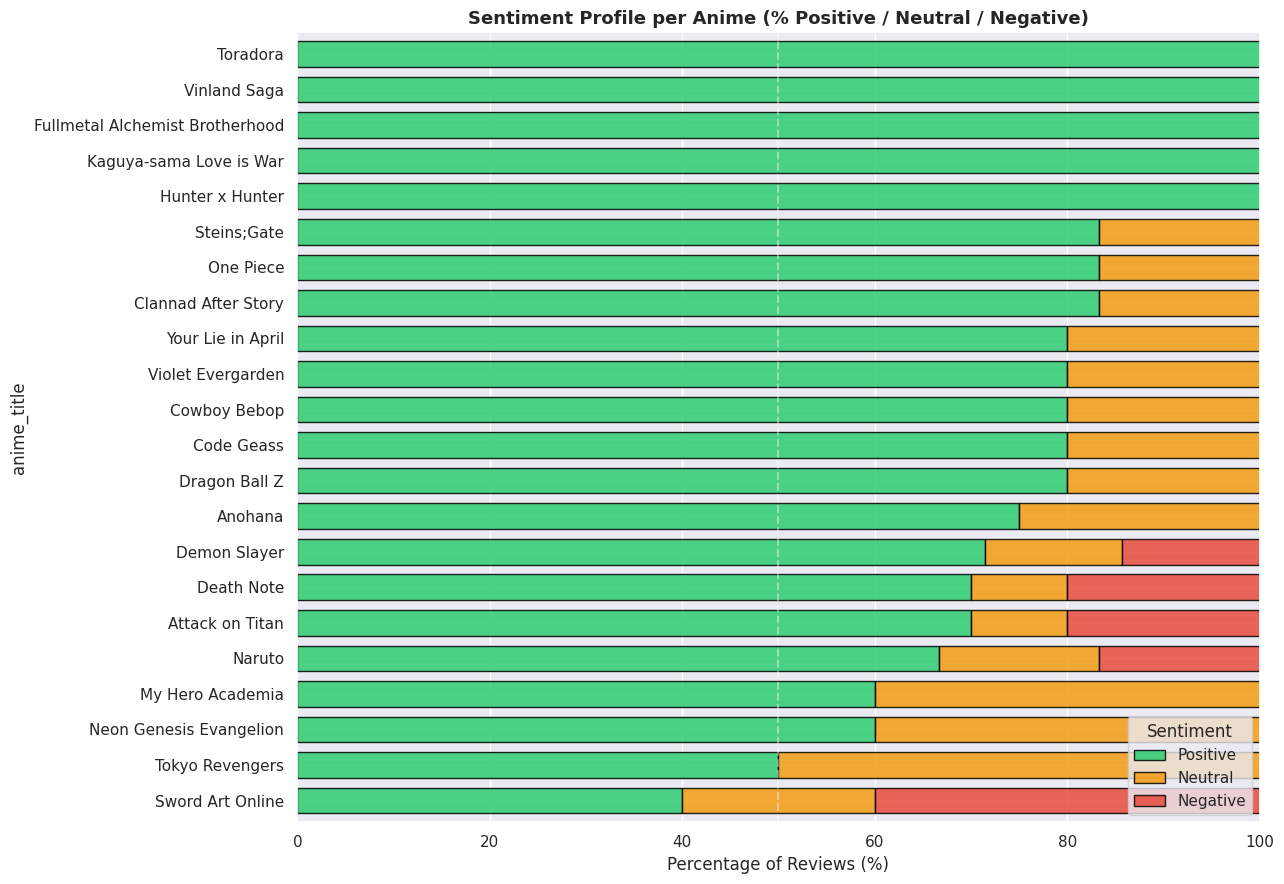

In [15]:
pivot = (df.groupby(['anime_title', 'sentiment'])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=['Positive', 'Neutral', 'Negative'], fill_value=0))
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100
pivot_pct = pivot_pct.sort_values('Positive', ascending=True)

fig, ax = plt.subplots(figsize=(13, 9))
pivot_pct.plot(kind='barh', stacked=True, ax=ax,
               color=['#2ecc71', '#f39c12', '#e74c3c'],
               edgecolor='black', alpha=0.85, width=0.72)
ax.axvline(50, color='white', linestyle='--', alpha=0.4)
ax.set_xlabel('Percentage of Reviews (%)')
ax.set_title('Sentiment Profile per Anime (% Positive / Neutral / Negative)',
             fontweight='bold', fontsize=13)
ax.legend(title='Sentiment', loc='lower right')
plt.tight_layout()
plt.show()


## 11. 🚀 AniSense — Full Inference Demo

In [16]:
# Out-of-fold sentiment predictions from the best-macro-F1 ML model, so the per-anime report is
# NOT produced by a model that was trained on those same reviews.
ml_names  = [m for m in models if m != 'Majority baseline']
best_ml   = max(ml_names, key=lambda m: results_df.loc[m, 'F1 Macro'])
df['sent_pred_cv'] = oof_preds[best_ml]
print(f'Sentiment model used in reports: {best_ml} (cross-validated predictions)\n')

def anisense(anime_name, top_n=5):
    """AniSense complete NLP report for a given anime."""
    if anime_name not in ANIME_META:
        print(f'Unknown: {anime_name}')
        return

    reviews = df[df['anime_title'] == anime_name]
    if reviews.empty:
        print(f'No reviews for: {anime_name}')
        return

    total    = len(reviews)
    pred_cnt = Counter(reviews['sent_pred_cv'])
    true_cnt = Counter(reviews['sentiment'])
    top_kw   = [k for k, _ in top_keywords(anime_name)]
    recs     = recommend(anime_name, top_n=top_n)

    print('=' * 70)
    print(f'  ANISENSE REPORT : {anime_name}')
    print('=' * 70)
    print(f'  Genre           : {ANIME_META[anime_name]["genre"]}')
    print(f'  Avg Rating      : {reviews["rating"].mean():.2f}/10  ({total} reviews)')
    print(f'  Sentiment (from ratings)  : '
          f'Pos {true_cnt.get("Positive",0)} | Neu {true_cnt.get("Neutral",0)} | Neg {true_cnt.get("Negative",0)}')
    print(f'  Sentiment (model, CV)     : '
          f'Pos {pred_cnt.get("Positive",0)} | Neu {pred_cnt.get("Neutral",0)} | Neg {pred_cnt.get("Negative",0)}')
    print(f'  Top Keywords    : {", ".join(top_kw)}')
    print('-' * 70)
    print(f'  TOP {top_n} RECOMMENDATIONS:')
    for rank, (_, r) in enumerate(recs.iterrows(), start=1):
        print(f'   {rank}. {r["Recommended Anime"]:<33}'
              f'[{r["Genre"]}]  '
              f'Sim:{r["Similarity Score"]:.3f}  '
              f'Avg:{r["Avg Rating"]}/10  '
              f'Pos:{r["Positive %"]}')
    print('=' * 70)
    print()

for title in ['Attack on Titan', 'Steins;Gate', 'Your Lie in April',
              'Cowboy Bebop', 'Demon Slayer', 'Death Note']:
    anisense(title)

# Free-text input (the "Review Text" path from the pipeline diagram)
def predict_review(text):
    """Sentiment prediction for an arbitrary review using the final model fitted on all data."""
    clean = preprocess(text)
    probs = final_pipe.predict_proba([clean])[0]
    label = final_pipe.classes_[int(np.argmax(probs))]
    return label, dict(zip(final_pipe.classes_, np.round(probs, 3)))

print('--- Free-text sentiment demo ---')
for sample in [
    'Absolutely stunning animation and an unforgettable soundtrack, a true masterpiece.',
    'It was fine, some good arcs but the pacing dragged in the middle.',
    'Boring, predictable and the ending felt rushed. Big disappointment.',
]:
    label, probs = predict_review(sample)
    print(f'  "{sample[:60]}..." -> {label}  {probs}')

Sentiment model used in reports: Complement NB (cross-validated predictions)

  ANISENSE REPORT : Attack on Titan
  Genre           : Action
  Avg Rating      : 7.30/10  (10 reviews)
  Sentiment (from ratings)  : Pos 7 | Neu 1 | Neg 2
  Sentiment (model, CV)     : Pos 9 | Neu 1 | Neg 0
  Top Keywords    : season, titan battle, political, animation, plot
----------------------------------------------------------------------
  TOP 5 RECOMMENDATIONS:
   1. Code Geass                       [Thriller]  Sim:0.182  Avg:8.6/10  Pos:80%
   2. My Hero Academia                 [Action]  Sim:0.149  Avg:7.0/10  Pos:60%
   3. Vinland Saga                     [Action]  Sim:0.132  Avg:8.8/10  Pos:100%
   4. Fullmetal Alchemist Brotherhood  [Adventure]  Sim:0.124  Avg:9.0/10  Pos:100%
   5. Demon Slayer                     [Action]  Sim:0.119  Avg:8.0/10  Pos:71%

  ANISENSE REPORT : Steins;Gate
  Genre           : Sci-Fi
  Avg Rating      : 8.50/10  (6 reviews)
  Sentiment (from ratings)  : Pos 5 | Ne

## 12. 📋 Final Performance Summary

In [17]:
print('=== ANISENSE — FINAL PERFORMANCE SUMMARY ===')
print()
print('Sentiment classifiers (5x5 stratified CV):')
print(results_df[['Accuracy (%)', 'F1 Macro', 'F1 Weighted']].to_string())
best_row = results_df.drop('Majority baseline')['F1 Macro'].idxmax()
print(f'\nBest by Macro-F1 : {best_row}')
print()
print(f'Lexicon (optimistic, hand-tuned) : Accuracy {lex_acc*100:.2f}% | Macro-F1 {lex_f1:.4f}')
print(f'Genre (best grouped CV on reviews): {best_acc*100:.2f}%  vs majority baseline {base_rev*100:.2f}%')
print()
print('Recommendation Engine:')
print(f'  Method      : TF-IDF Cosine Similarity (no ground truth, qualitative only)')
print(f'  Anime cover : {len(anime_list)} titles | Features: {len(anime_features)}')
print()
print('=== PROJECT COMPLETE — ANISENSE ===')

=== ANISENSE — FINAL PERFORMANCE SUMMARY ===

Sentiment classifiers (5x5 stratified CV):
                     Accuracy (%)  F1 Macro  F1 Weighted
Majority baseline           77.78    0.2916       0.6808
Naive Bayes (MNB)           77.78    0.2916       0.6808
Complement NB               82.86    0.4732       0.7925
Logistic Regression         80.32    0.3718       0.7289
Linear SVM                  79.05    0.3352       0.7065

Best by Macro-F1 : Complement NB

Lexicon (optimistic, hand-tuned) : Accuracy 73.02% | Macro-F1 0.6359
Genre (best grouped CV on reviews): 26.98%  vs majority baseline 25.40%

Recommendation Engine:
  Method      : TF-IDF Cosine Similarity (no ground truth, qualitative only)
  Anime cover : 22 titles | Features: 1000

=== PROJECT COMPLETE — ANISENSE ===


## 13. 📝 Conclusion

### NLP Techniques Applied

| Technique | Applied To |
|:---|:---|
| Text Preprocessing | Regex + lemmatisation on 126 anime reviews |
| TF-IDF Vectorisation | Review-to-vector for sentiment, keyword and similarity tasks |
| Lexicon-Based Sentiment | Hand-written anime vocabulary (optimistic baseline, see caveats) |
| Naive Bayes (Multinomial / Complement) | Sentiment classification, genre prediction |
| Logistic Regression, Linear SVM | Class-balanced sentiment and genre classifiers |
| TF-IDF Keyword Extraction | Signature themes per anime (de-duplicated n-grams) |
| Cosine Similarity | Anime-to-anime recommendation engine |

### Key Findings (5×5 stratified CV; reproducible with `RANDOM_STATE = 42`)
1. **Class imbalance dominates sentiment results.** 77.8% of reviews are Positive. Plain Multinomial NB scores exactly
   the same as an "always Positive" baseline (77.8% accuracy, Macro-F1 0.29).
2. **Complement NB is the best sentiment model here** (≈82.9% accuracy, Macro-F1 ≈0.47), ahead of class-balanced
   Logistic Regression (≈80.3%, ≈0.37) and Linear SVM (≈79.1%, ≈0.34). The gaps are small relative to the fold-to-fold
   standard deviation (Macro-F1 std ≈0.06–0.10), so the ranking among the three is not statistically solid.
   In the out-of-fold confusion matrices **no model correctly identifies a single Negative review (0 of 8)**, and
   Logistic Regression / SVM still lean almost entirely on "Positive". Treat all of them as weak.
3. **The lexicon baseline is not comparable.** Its Macro-F1 (≈0.64) looks better than the ML models, but the word list
   was written around this dataset (34 of 39 positive words occur in the corpus), has no negation handling, and is
   scored on the same data it was designed from.
4. **Genre classification does not work with this data.** The original 100% accuracy was data leakage (shuffled copies of
   the same plot in both train and test). With leakage removed, plot-based leave-one-out accuracy is 0% and
   review-based grouped CV reaches only ≈27% against a ≈25% majority baseline.
5. **The recommender is qualitative only.** Similarities are driven by review wording, there is no ground truth to score
   them, and a few titles act as "hubs" that appear in many lists. For example, *Steins;Gate* → *Toradora* ranks above
   *Death Note*, which is hard to justify thematically.

### What to do next (in order of impact)
- **Collect far more data** (thousands of reviews, balanced across ratings). Nothing else matters as much.
- Replace the 3-class rating mapping with a task that matches the data (e.g. rating regression) or label the text itself.
- Fine-tune a pretrained model (**BERT / DistilBERT**) on real MyAnimeList reviews.
- Build recommendations from plots + metadata + user–item ratings (**collaborative filtering**) and evaluate them with held-out user ratings.
- Add **Aspect-Based Sentiment Analysis** (Story / Animation / Music / Characters) and a **Streamlit** front end.